# P8_1D

Este notebook te mostrará como utilizar los procesos Gausianos para resolver un problema de regresión de 1D. 

Esta parte es adaptada de una práctica hecha por *Ruben Martínez-Cantín* (basada en "*GPSS labs*")

## Nombre: David Jiménez Omeñaca

## NIP: 825068

In [1]:
import numpy as np
import scipy
from matplotlib import pyplot as plt
from matplotlib import rcParams
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    ExpSineSquared,
    RationalQuadratic,
    WhiteKernel,
    Matern,
)
import pandas as pd

pd.set_option('display.float_format', lambda x: f'{x:.3f}')

%matplotlib inline

Comenzamos con funciones auxiliares para analizar los datos

In [8]:
def plot_gp2(X, m, std_pred, training_points=None, ax=None, only_training=None):
    """Plotting utility to plot a GP fit with 95% confidence interval"""
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = None

    # Plot the mean prediction
    ax.plot(X, m, label="Mean prediction")
    # Plot the 95% confidence interval
    ax.fill_between(
        X.ravel(),
        m - 1.96 * std_pred,
        m + 1.96 * std_pred,
        alpha=0.5,
        label=r"95% confidence interval",
    )

    # Plot the training points if provided
    if training_points is not None:
        X_, Y_ = training_points
        ax.plot(X_, Y_, "kx", mew=1, ms=4, alpha=0.2, label="All points")
    
    if only_training is not None:
        X_, Y_ = only_training
        ax.plot(X_, Y_, "rx", mew=1, ms=5, alpha=1, label="Training points")

    ax.set(xlabel="$x$", ylabel="$f(x)$")
    ax.legend()
    
    if fig:
        fig.tight_layout()

    return fig, ax


class GPAnalyzer:
    def __init__(self, gpr, kernel_title="", parameters={}):
        self._gpr = gpr
        self.kernel_title = kernel_title
        self.parameters = parameters
        self.time_fit = 0
    def fit(self, X, y):
        import time
        start = time.time()
        self._gpr.fit(X, y)
        self.time_fit = time.time() - start
    def get_log_likelihood_on_data(self, X, y):
        mean, std = self._gpr.predict(X, return_std=True)
        var = std**2
        log_lik = 0.5 * np.sum(((y - mean)**2) / var + np.log(2 * np.pi * var))
        return log_lik
    def get_MSE(self, X, y):
        y_pred = self._gpr.predict(X)
        return np.mean((y - y_pred) ** 2)
    def get_kernel(self):
        return self._gpr.kernel_
    def plot_gp2(self, range=np.linspace(733800, 735400, 100)[:, None], ax=None, sampled=None):
        mean_prediction, std_prediction = self._gpr.predict(range, return_std=True)
        if ax is None:
            fig, ax = plot_gp2(range, mean_prediction, std_prediction, training_points=(X, y), only_training=sampled)
            return fig, ax
        else:
            # Plot into provided ax
            plot_gp2(range, mean_prediction, std_prediction, training_points=(X, y), ax=ax, only_training=sampled)
            ax.set_title(self.kernel_title if self.kernel_title else "GP")
            return None, ax
    def get_pd_results(self, X, y):
        import pandas as pd
        parameters_names = list(self.parameters.keys())
        parameters_values = list(self.parameters.values())
        results = pd.DataFrame(
            columns=["name", "n-log-m-lik", "mse"] + parameters_names + ["time-fit"],
        )
       
        results.loc[0] = [self.kernel_title, 
                          self.get_log_likelihood_on_data(X, y),
                          self.get_MSE(X, y)] + \
                          parameters_values + \
                          [self.time_fit]
        return results
    
    def print_parameters_summary(self):
        import pandas as pd
        parameters_initial = np.exp(self._gpr.kernel.theta)
        parameters_optimized = np.exp(self._gpr.kernel_.theta)
        
        print(f"Model: {self.kernel_title}")
        print(f"\tInitial parameters: {parameters_initial}")
        print(f"\tOptimized parameters: {parameters_optimized}")

class GPsAnalizer:
    def __init__(self, gpr_list, parameter_names=[]):
        self.parameter_names = ["name", "n-log-m-lik", "mse"] + parameter_names + ["time-fit"]
        self.gpr_list = gpr_list
    def get_table_results(self, X, y):
        import pandas as pd
        results_list = [gpr.get_pd_results(X, y) for gpr in self.gpr_list]
        results = pd.concat(results_list, ignore_index=True)
        results.sort_values(by="n-log-m-lik", ascending=True, inplace=True)
        return results
    
    def print_parameters_summary(self):
        for gpr in self.gpr_list:
            gpr.print_parameters_summary()


    def plot_gp2(self, ncols, nrows, range=np.linspace(733800, 735400, 100)[:, None], sampled = None):
        assert len(self.gpr_list) == ncols * nrows, "Number of GPs does not match the grid size"

        fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4))
        axs = axs.flatten()

        for i, (gpr, ax) in enumerate(zip(self.gpr_list, axs)):
            gpr.plot_gp2(range=range, ax=ax, sampled=sampled)

        fig.tight_layout()
        return fig, axs

    def plot_overlay(self, range=np.linspace(733800, 735400, 100)[:, None]):
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Color cycle
        color_cycle = plt.colormaps.get_cmap('tab10')

        # Plot each GP
        for i, gpr in enumerate(self.gpr_list):
            mean_pred, std_pred = gpr._gpr.predict(range, return_std=True)
            label = gpr.kernel_title if gpr.kernel_title else f"Model {i+1}"
            color = color_cycle(i)

            ax.plot(range, mean_pred, label=label, color=color)
            ax.fill_between(
                range.ravel(),
                mean_pred - 1.96 * std_pred,
                mean_pred + 1.96 * std_pred,
                alpha=0.3,
                color=color
            )

        # Plot training points (assuming they are shared)
        if len(self.gpr_list) > 0:
            gpr0 = self.gpr_list[0]
            ax.plot(X, y, "kx", mew=1, ms=4, alpha=0.5, label="Training points")

        ax.set_xlabel("$x$")
        ax.set_ylabel("$f(x)$")
        ax.set_title("Overlay of GP Predictions")
        ax.legend()
        fig.tight_layout()
        return fig, ax


## 1) Datos utilizados

Se presentan ahora el dataset 1D que se va a ajustar con procesos gaussianos:


Tamaño de X: (842, 1)
Tamaño de y: (842, 1)


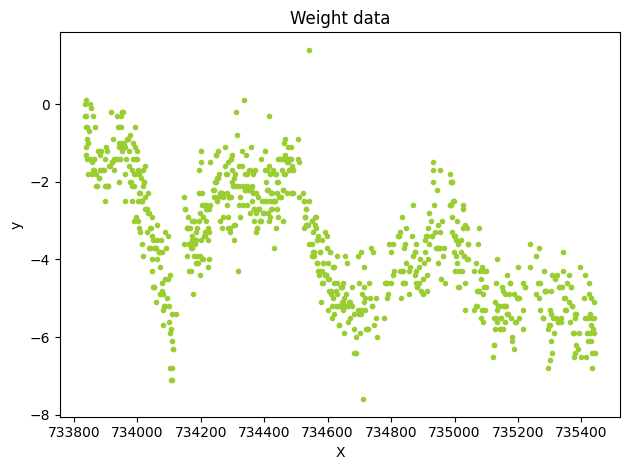

In [9]:
# Load the weight dataset
data = scipy.io.loadmat("weightdata_clean.mat")
X, y = data["dat"][:, 0:1], data["dat"][:, 1:]

# set the step to subsample the dataset
subsample = 1
X = X[::subsample]
y = y[::subsample]

# Make sure the data is there
print(f"Tamaño de X: {X.shape}")
print(f"Tamaño de y: {y.shape}")

# Plot the data
fig, ax = plt.subplots()
ax.scatter(X, y, color="yellowgreen", marker=".")
ax.set(xlabel="X", ylabel="y", title="Weight data")
fig.tight_layout()

# 1.a) Ajuste manual utilizando kernel RBF

Comenzamos el análisis utilizando un kernel RBF, que tiene la siguiente forma

$$
    \kappa_\mathrm{rbf}(x,x') = \sigma^2\exp\left(-\frac{(x-x')^2}{2\mathscr{l}^2}\right)
$$
Tiene dos parámetros, la varianza $\sigma^2$ y la escala $\mathscr{l}$. Vamos a plotear para diferentes valores de estos parámetros

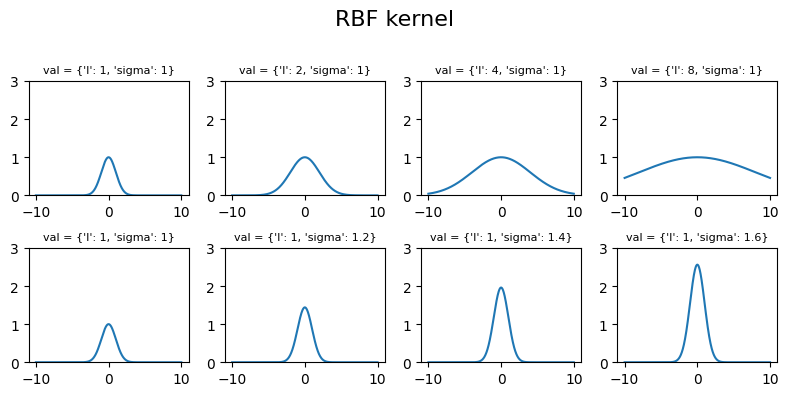

In [10]:
def plot_range(f, vals, ncol, nrow, title, x_range):
    assert ncol * nrow == len(vals), "ncol * nrow != len(vals)"
    
    fig, ax = plt.subplots(ncol, nrow, figsize=(nrow * 2, ncol * 2))

    for (i, val) in enumerate(vals):
        row = i // nrow
        col = i % nrow
        ax[row, col].plot(x_range, f(x_range, **val), label=f"val = {val}")
        ax[row, col].set_ylim(0, 3)  # Set the y-axis range
        ax[row, col].set_title(f"val = {val}", fontsize=8)

    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.subplots_adjust(top=0.8)
    plt.show()

def RGF_1D(x, sigma, l):
    return sigma**2 * np.exp(-0.5 * (x / l) ** 2)

ranges = [
    {"l": 1, "sigma": 1},
    {"l": 2, "sigma": 1},
    {"l": 4, "sigma": 1},
    {"l": 8, "sigma": 1},

    {"l": 1, "sigma": 1},
    {"l": 1, "sigma": 1.2},
    {"l": 1, "sigma": 1.4},
    {"l": 1, "sigma": 1.6},
]

x_range = np.linspace(-10, 10, 1000)

plot_range(RGF_1D, ranges, 2, 4, "RBF kernel", x_range)




Podemos ver que:
- Al incrementar $l$, se da más importancia a los valores más lejanos.
- Al incrementar $\sigma$, simplemente se escala la importancia.
- Ambos valores **DEPENDEN** de la escala en la que estén los datos, ya que $l$ refleja una distancia entre dos valores distintos.

Para el primer modelo, como tenemos muchos datos, vamos a utilizar un valor $l$ pequeño (en la escala de los datos) de $25$ y un sigma de $1.24$. Así:

In [11]:
# Define a kernel
sigma = 1.24**2
l = 25
kernel_1 = sigma * RBF(length_scale=l)

Ahora, ajustamos el kernel gaussiano sin optimizar los parámetros del kernel:

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='$x$', ylabel='$f(x)$'>)

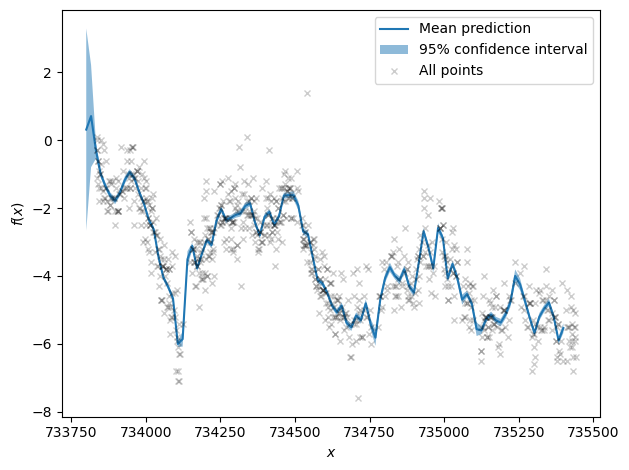

In [12]:
gpr = GaussianProcessRegressor(
    kernel=kernel_1, normalize_y=True, alpha=0.1**2, optimizer=None
)

gpr_analyzer = GPAnalyzer(gpr, 
                          kernel_title="RBF kernel no optimization",
                          parameters={"l": l, "sigma": sigma})

gpr_analyzer.fit(X, y)

gpr_analyzer.plot_gp2()

Junto a los resultados numéricos:

In [13]:
gpr_analyzer.get_pd_results(X, y)

,name,n-log-m-lik,mse,l,sigma,time-fit
0,RBF kernel no optimization,695013419.696,4.531,25,1.538,0.106


Aquí podemos observar:
- El ajuste resulta estar muy determinado (intervalo de confianza muy pequeño), en casi todo los puntos menos al comienzo debido a que faltan observaciones.

Ahora vamos a analizar con otros valores para poder analizar las diferencias

In [14]:
ls = [25, 50, 100]
sigmas = [1.24, 3]

list_gps = []

for l in ls:
    for sigma in sigmas:
        kernel = sigma**2 * RBF(length_scale=l)
        gpr = GaussianProcessRegressor(
            kernel=kernel, normalize_y=True, alpha=0.1**2, optimizer=None
        )
        gpr_analyzer = GPAnalyzer(gpr, 
                                  kernel_title=f"RBF kernel l={l}, sigma={sigma}",
                                  parameters={"l": l, "sigma": sigma})
        gpr_analyzer.fit(X, y)
        list_gps.append(gpr_analyzer)
        
gps_ = GPsAnalizer(list_gps, parameter_names=["l", "sigma"])

gps_.get_table_results(X, y)

,name,n-log-m-lik,mse,l,sigma,time-fit
1,"RBF kernel l=25, sigma=3",633028949.751,4.540,25,3.000,0.102
0,"RBF kernel l=25, sigma=1.24",695013419.696,4.531,25,1.240,0.153
3,"RBF kernel l=50, sigma=3",1150832318.035,4.483,50,3.000,0.078
2,"RBF kernel l=50, sigma=1.24",1257395790.455,4.476,50,1.240,0.074
5,"RBF kernel l=100, sigma=3",2099415664.859,4.442,100,3.000,0.073
4,"RBF kernel l=100, sigma=1.24",2286996086.845,4.436,100,1.240,0.071


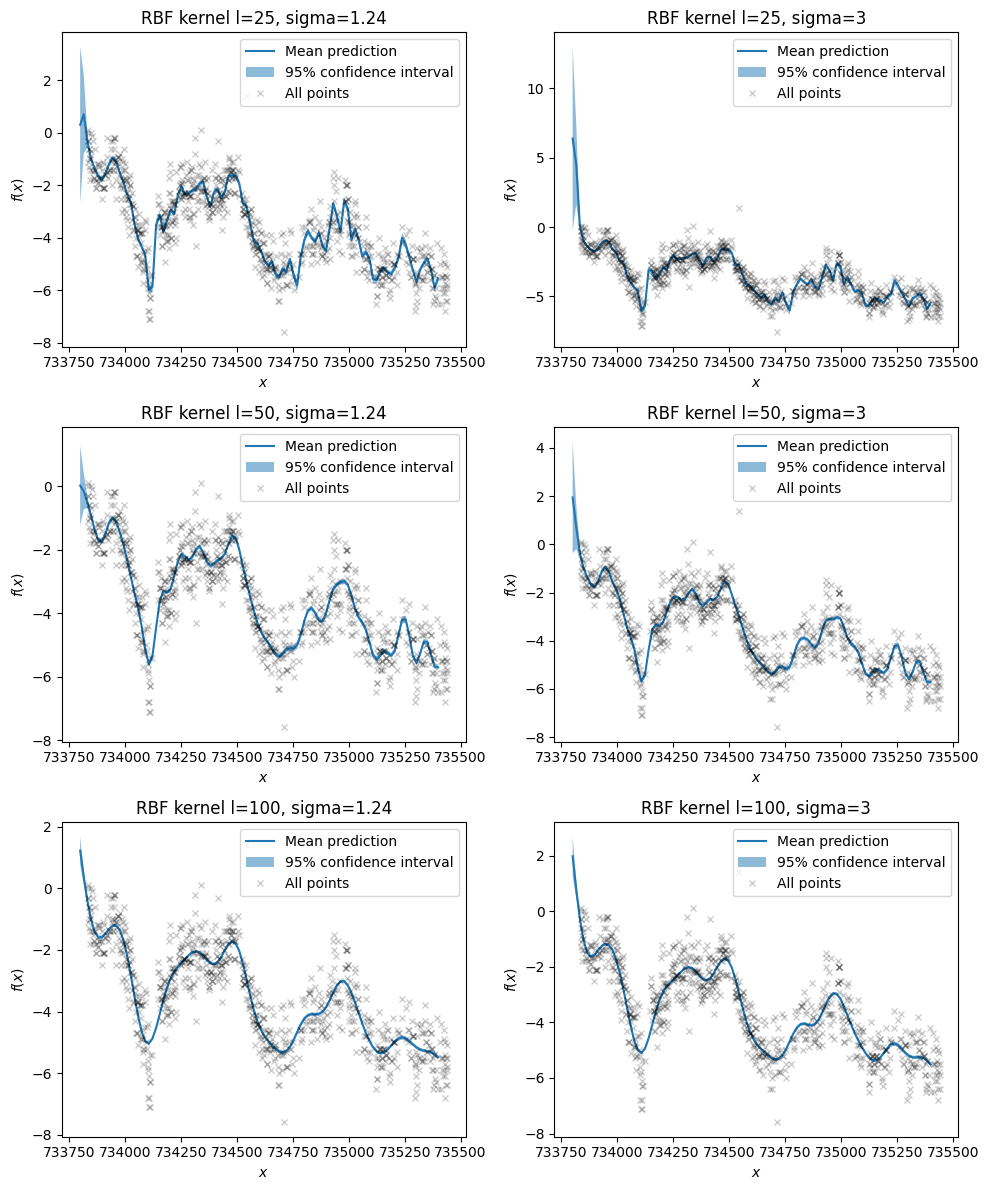

In [15]:
gps_.plot_gp2(2, 3)
plt.show()

Aquí se puede ver:
- El mejor modelo se obtiene con $l=25$ y $\sigma=1.24$.
- Al aumentar $l$ la incertidumbre del extremo izquierdo se reduce, debido a que las observaciones lejanas tienen más peso.
- El considerar más vecinos también hace que el ajuste sea peor, pero disminuye la incertidumbre general.
- Al aumentar sigma, cuando hay zonas con menos observaciones, las predicciones se desvian más.

## 1.b) Explorar nuevos kernels

Ahora vamos a probar con otros tres kernels:
- **Kernel Periódico** debido a que los datos parecen tener una tendencia periódica, multiplicado por un **RBF**.
- **Kernel Matèrn** por su uso extendido en campos como la meteorología.
Se van a elegir parámetros por defecto para los diferenets Kernels.
- **Kernel RBF** con medida de **ruido** para poder ajustar el ruido presente en los datos.

Para el kernel periódico:
- Tomamos $l$ el mismo que antes, ya que controla lo mismo
- Tomamos $p$ igual a $500$, ya que el periodo en los datos parece ser este valor.

Para el kernel Matèrn:
- Tomamos $l$ igual
- Tomamos $\nu=3/2$ ya que la función no parece infinitamente derivable (ver [link](https://scikit-learn.org/stable/modules/gaussian_process.html#mathematical-implementation-of-mat%C3%A9rn-kernel))

Para el kernel RBF:
- Se toman los paráemtros obtenidos anteriormente

Para el kernel de ruido:
- Nivel de ruido $\sigma=0.1$.


In [16]:
per_kernel = ConstantKernel(1.24**2) * ExpSineSquared(length_scale=25, periodicity=500) + RBF(length_scale=25)
per_matern = ConstantKernel(1.24**2)  * Matern(length_scale=25, nu=1.5)
per_noise = ConstantKernel(1.24**2) * RBF(length_scale=25) +  WhiteKernel(noise_level=0.66**2, noise_level_bounds=(1e-5, 1e5))


gpr_list = []
for kernel, name in zip([per_kernel, per_matern, per_noise], ["ExpSineSquared + RBF", "Matern", "Noise + RBF"]):
    gpr = GaussianProcessRegressor(
        kernel=kernel, normalize_y=True, alpha=0.1**2, optimizer=None
    )
    gpr_analyzer = GPAnalyzer(gpr, 
                              kernel_title=name)
    gpr_analyzer.fit(X, y)
    gpr_list.append(gpr_analyzer)

gpr_list = GPsAnalizer(gpr_list)

gpr_list.get_table_results(X, y)


,name,n-log-m-lik,mse,time-fit
2,Noise + RBF,2077450.616,4.460,0.111
1,Matern,210235779.278,4.625,0.075
0,ExpSineSquared + RBF,713117535.498,4.529,0.148


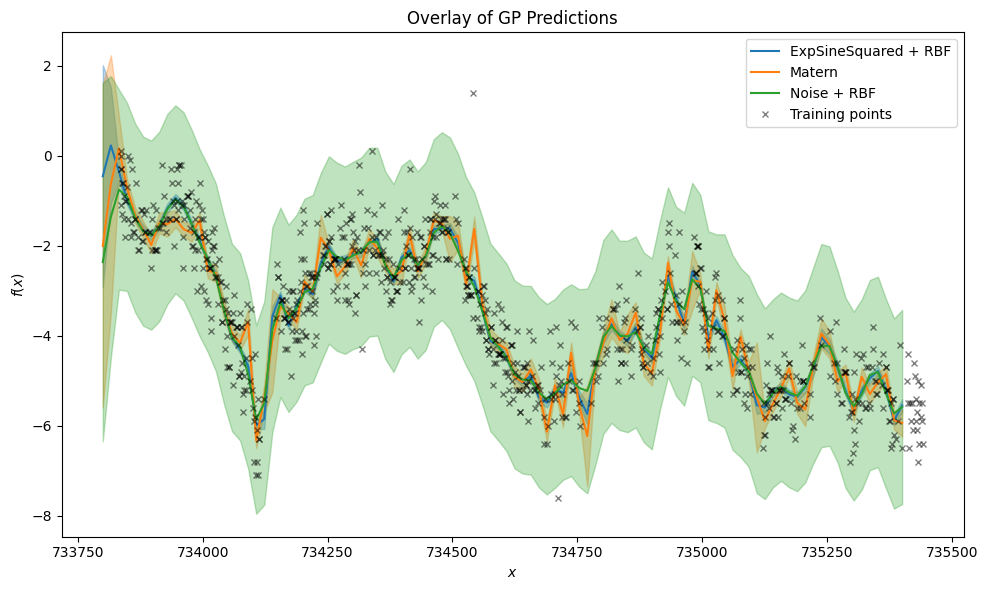

In [17]:
gpr_list.plot_overlay()
plt.show()

Aquí:
- Añadir una componente de ruido ha permitido evitar que ante datos atípicos , el modelo se sobreajuste hacia estos, algo que `Matern` está fallando.
- Eso hace que `RBF + Noise` sea menos errático y más 'continuo'.
- Sin embargo, añadir ruido provoca una mayor incertidumbre.
- Además, este modelo ha dado los mejores resultados tanto en verosimilitud como en MSE.
- El kernel periódico, tiene menos incertidumbre debido a la composición del kernel, lo que afecta a su verosimilitud.


## 1.c) Optimización de parámetros

Ahora vamos a modelar estos kernels permitiendo la optimización de los hiperparámetros. Además, vamos a ejecutarlo con distintos valores iniciales para ver si eso afecta al óptimo alcanzado. Vamos a probar con los valores iniciales tomados anteriormente y otros más extremos.

In [18]:
per_kernel_ex = ConstantKernel(2**2) * ExpSineSquared(length_scale=200, periodicity=500) + RBF(length_scale=200)
per_matern_ex = ConstantKernel(2**2)  * Matern(length_scale=200, nu=1.5)
per_noise_ex = ConstantKernel(2**2) * RBF(length_scale=200) +  WhiteKernel(noise_level=2**2, noise_level_bounds=(1e-5, 1e5))

gpr_list_ex = []

for kernel, name in zip([per_kernel, per_kernel_ex, per_matern, per_matern_ex, per_noise, per_noise_ex], 
                        ["ExpSineSquared + RBF", "ExpSineSquared + RBF (ex)", 
                         "Matern", "Matern (ex)", "Noise + RBF", "Noise + RBF (ex)"]):
    gpr = GaussianProcessRegressor(
        kernel=kernel, normalize_y=True, alpha=0.1**2
    )
    gpr_analyzer = GPAnalyzer(gpr, 
                              kernel_title=name)
    gpr_analyzer.fit(X, y)
    gpr_list_ex.append(gpr_analyzer)

gpr_list_ex = GPsAnalizer(gpr_list_ex)

gpr_list_ex.get_table_results(X, y)

,name,n-log-m-lik,mse,time-fit
5,Noise + RBF (ex),3925092.801,4.436,2.469
4,Noise + RBF,4150098.897,4.462,1.842
0,ExpSineSquared + RBF,72157660.294,4.871,7.980
1,ExpSineSquared + RBF (ex),74478239.788,4.858,22.084
3,Matern (ex),76059281.295,4.852,3.996
2,Matern,76059285.937,4.852,6.993


Aquí:
- En cuestion de `MSE`, los mejores resultados son los obtenidos con ajuste automático de parámetros.

Ahora veamos los parámetros optimizados:

In [19]:
np.set_printoptions(suppress=True, precision=3)
gpr_list_ex.print_parameters_summary()

Model: ExpSineSquared + RBF
	Initial parameters: [  1.538  25.    500.     25.   ]
	Optimized parameters: [  0.346   0.611 542.863   0.   ]
Model: ExpSineSquared + RBF (ex)
	Initial parameters: [  4. 200. 500. 200.]
	Optimized parameters: [  0.006   1.015 135.32    1.157]
Model: Matern
	Initial parameters: [ 1.538 25.   ]
	Optimized parameters: [0.883 2.357]
Model: Matern (ex)
	Initial parameters: [  4. 200.]
	Optimized parameters: [0.883 2.357]
Model: Noise + RBF
	Initial parameters: [ 1.538 25.     0.436]
	Optimized parameters: [ 0.632 26.208  0.157]
Model: Noise + RBF (ex)
	Initial parameters: [  4. 200.   4.]
	Optimized parameters: [ 0.638 41.903  0.171]


Aquí:
- En el Kernel Matèrn, desde diferentes puntos iniciales, se ha llegado al mismo óptimo.
- Para el resto de Kernels, el punto inicial ha afectado al **balanceo** de los parámetros. Por ejemplo, en el periódico más RBF, en uno de los modelos, se ha explicado más utilizando el término periódico, mientras que en el otro se ha ignorado.
- Esto recalca la importancia de empezar con valores iniciales realistas para que un kernel no **opaque** al otro.


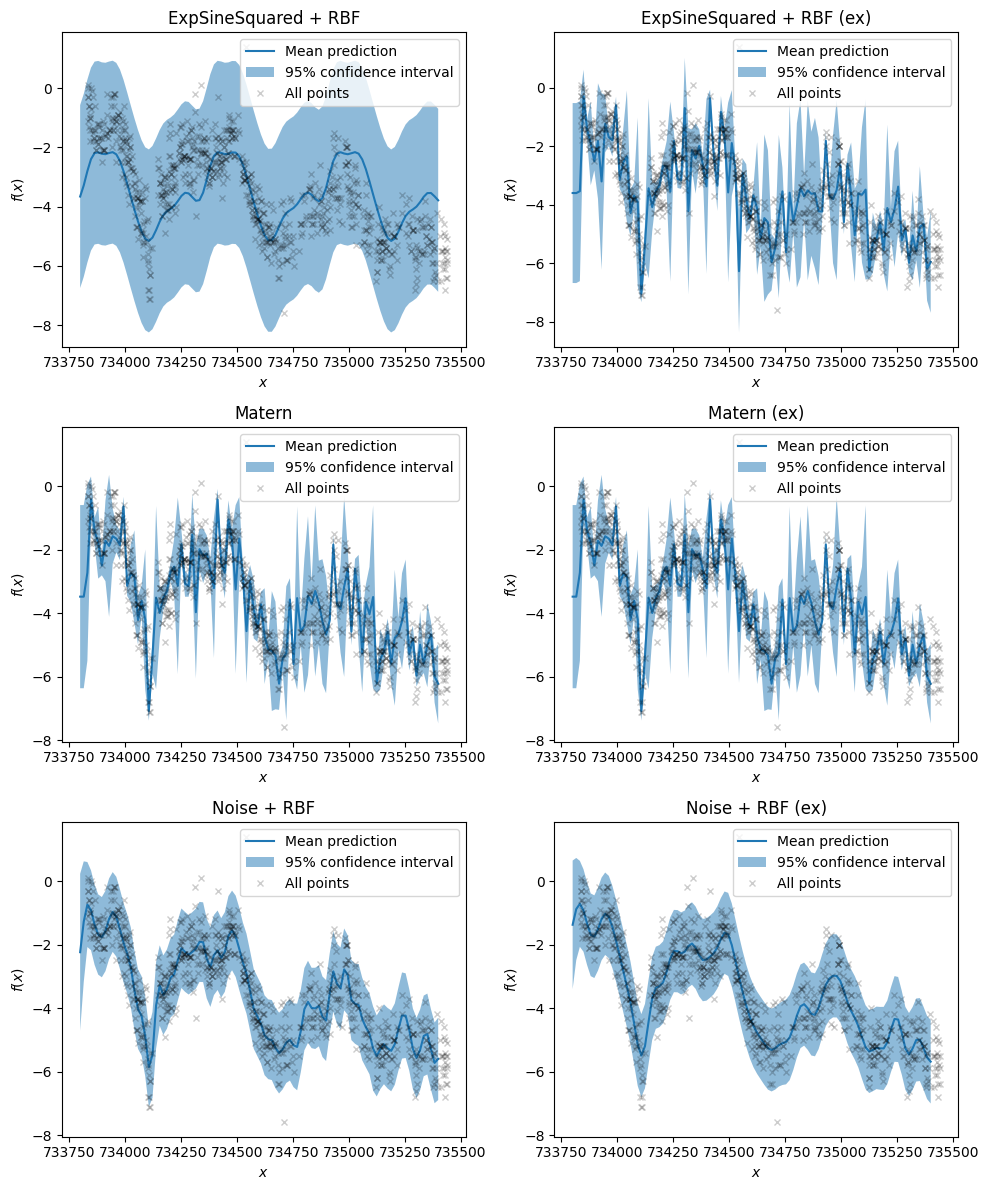

In [20]:
gpr_list_ex.plot_gp2(2, 3)
plt.show()

Con las gráficas llegamos a las conclusiones:
- La inclusión de ruido es muy importante para suavizar los modelos, evitando grandes cambios en la varianza del campo gaussiano debido a datos atípicos.
- Se ha detectado un nivel de ruido de $\sigma=0.157$.

Finalmente vamos a comparar los modelos utilizando optimización de parámetros y sin utilizar:

In [21]:
gpr_list_ex = []

for kernel, name, opt in zip([per_kernel, per_kernel, per_matern, per_matern, per_noise, per_noise], 
                        ["ExpSineSquared + RBF", "ExpSineSquared + RBF (opt)", 
                         "Matern", "Matern (opt)", "Noise + RBF", "Noise + RBF (opt)"],
                         [None, "fmin_l_bfgs_b", None, "fmin_l_bfgs_b", None, "fmin_l_bfgs_b"]):
    gpr = GaussianProcessRegressor(
        kernel=kernel, normalize_y=True, alpha=0.1**2, optimizer=opt
    )
    gpr_analyzer = GPAnalyzer(gpr, 
                              kernel_title=name)
    gpr_analyzer.fit(X, y)
    gpr_list_ex.append(gpr_analyzer)

gpr_list_ex = GPsAnalizer(gpr_list_ex)

gpr_list_ex.get_table_results(X, y)

,name,n-log-m-lik,mse,time-fit
4,Noise + RBF,2077450.616,4.460,0.111
5,Noise + RBF (opt),4150098.897,4.462,1.910
1,ExpSineSquared + RBF (opt),72157660.294,4.871,8.068
3,Matern (opt),76059285.937,4.852,7.117
2,Matern,210235779.278,4.625,0.073
0,ExpSineSquared + RBF,713117535.498,4.529,0.207


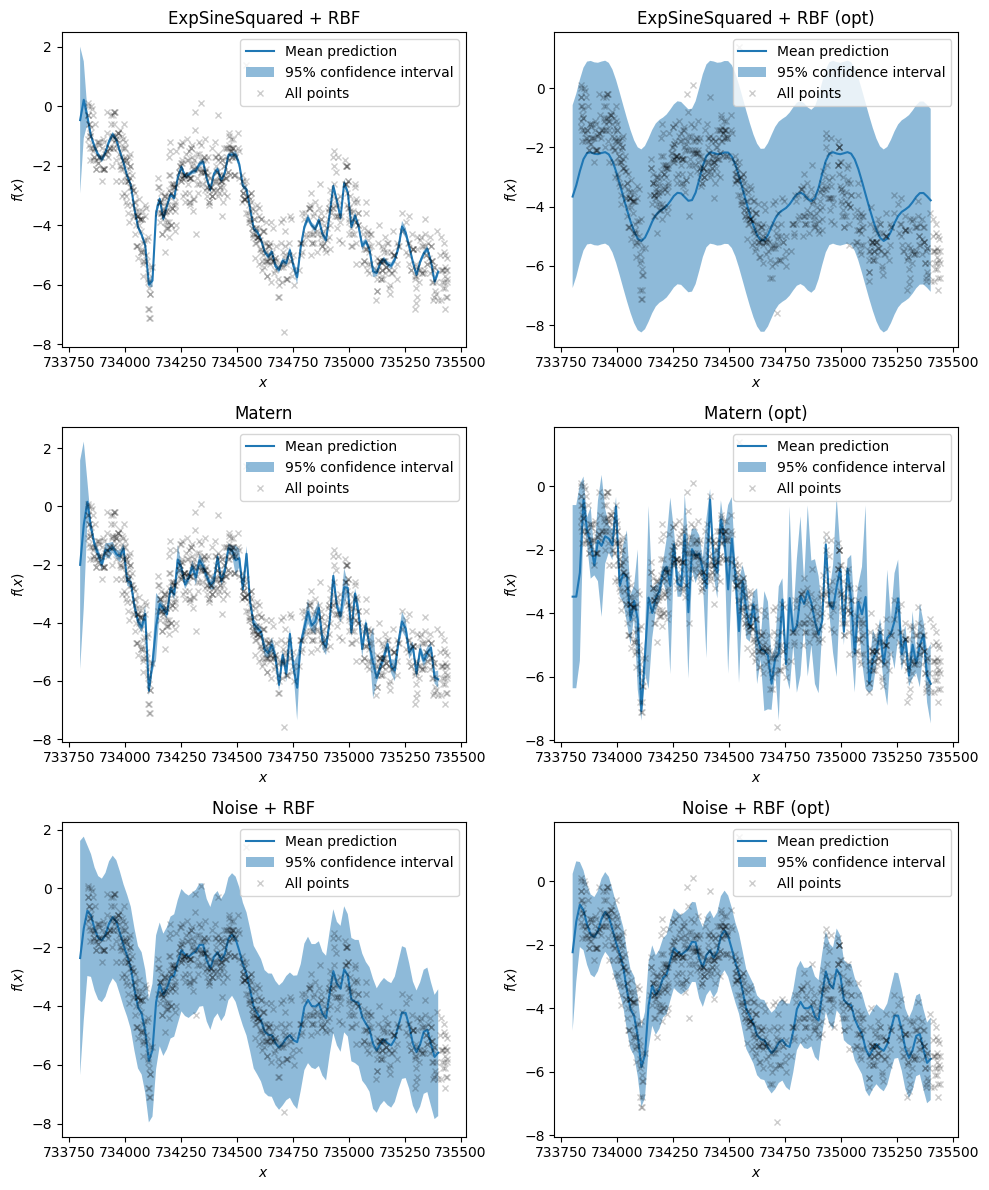

In [22]:
gpr_list_ex.plot_gp2(2, 3)
plt.show()

Aquí podemos ver que:
- Los modelos optimizados obtienen peor MSE pero mejor verosimilitud.
- Esto se debe a que la optimización prioriza modelos que expliquen mejor todos los datos.


## 1.d) Entrenamiento con menores muestras
El punto fuerte de los procesos gausianos es conseguir modelos cuando las muestras son bajas. Para ver esto, vamos a ajustar los 3 modelos entrenándolos solo con 20 muestras aleatorias y calculando el MSE para todas las muestras.

In [23]:
print(f"Tamaño inicial de X: {X.shape}")
print(f"Tamaño inicial de y: {y.shape}")

# Define the size of the subsample
n_subsample = 20
# Get the total number of samples
n_samples = X.shape[0]
# Generate random indices without replacement
random_indices = np.random.choice(n_samples, n_subsample, replace=False)
# Select the subsample using the random indices
X_subsample = X[random_indices]
y_subsample = y[random_indices]

print(f"Tamaño de X: {X_subsample.shape}")
print(f"Tamaño de y: {y_subsample.shape}")

gpr_list_ex = []

for kernel, name in zip([per_kernel, per_matern, per_noise], 
                        ["ExpSineSquared + RBF", "Matern", "Noise + RBF"]):
    gpr = GaussianProcessRegressor(
        kernel=kernel, normalize_y=True, alpha=0.1**2, optimizer=None
    )

    gpr_analyzer = GPAnalyzer(gpr, 
                              kernel_title=name)
    gpr_analyzer.fit(X_subsample, y_subsample)
    gpr_list_ex.append(gpr_analyzer)

gpr_list_ex = GPsAnalizer(gpr_list_ex)

gpr_list_ex.get_table_results(X, y)

Tamaño inicial de X: (842, 1)
Tamaño inicial de y: (842, 1)
Tamaño de X: (20, 1)
Tamaño de y: (20, 1)


,name,n-log-m-lik,mse,time-fit
2,Noise + RBF,1492241.738,3.343,0.004
1,Matern,5010214.901,3.579,0.003
0,ExpSineSquared + RBF,9132498.318,3.839,0.006


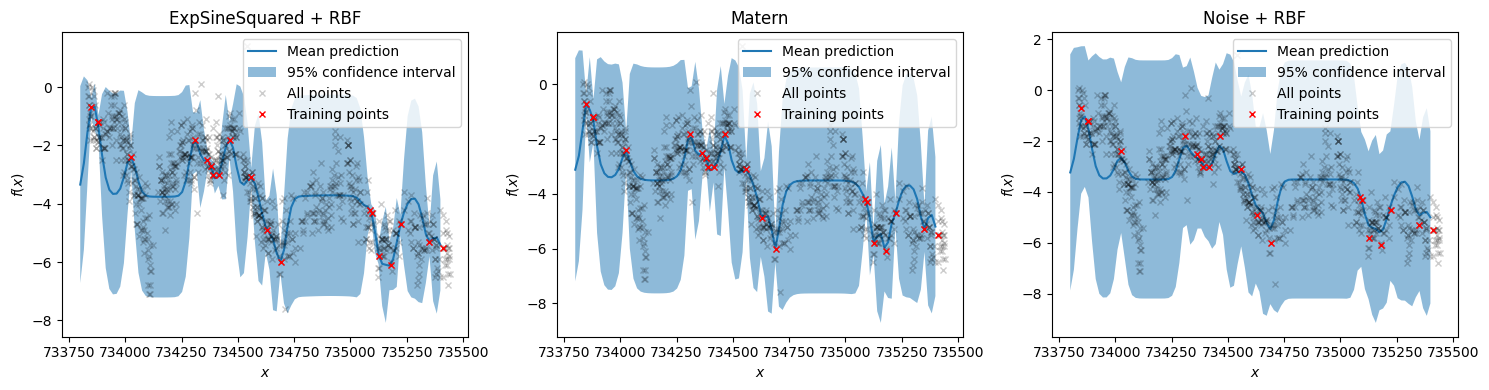

In [24]:
gpr_list_ex.plot_gp2(3, 1, sampled=(X_subsample, y_subsample))
plt.show()

Aquí podemos ver que:
- A pesar de tener pocas muestras, se ha obtenido un modelo razonable que logra explicar la mayoría de los datos.
- Se han conseguido resultados similares para los tres kérnels.
- La incertidumbre es muy alta en zonas con pocas observaciones